PART A - DATA PREPARATION


In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
# Loading Datasets
trader = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trader dataset shape:", trader.shape)
print("Sentiment dataset shape:", sentiment.shape)


Trader dataset shape: (27932, 16)
Sentiment dataset shape: (2644, 4)


In [3]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trader.columns
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [6]:
trader.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [7]:
sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [8]:
trader = trader.drop_duplicates()
sentiment = sentiment.drop_duplicates()

In [9]:
trader['Timestamp'] = pd.to_datetime(trader['Timestamp'], unit='ms')
trader['date'] = trader['Timestamp'].dt.date

In [10]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [11]:
# Merging two datasets
merged = pd.merge(trader, sentiment, on='date', how='left')
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed


PART B - ANALYSIS

In [12]:
merged['win'] = merged['Closed PnL'] > 0

In [13]:
avg_trade_size = merged['Size USD'].mean()
avg_trade_size

np.float64(22052.204851782903)

In [14]:
trades_per_day = merged.groupby('date').size()

In [15]:
merged['Side'].value_counts(normalize=True)

,proportion
Side,
BUY,0.508807
SELL,0.491193


In [16]:
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean()
pnl_by_sentiment

,Closed PnL
classification,
Extreme Greed,-9.681505
Fear,189.287392
Greed,5.446001
Neutral,76.747074


In [17]:
win_rate = merged.groupby('classification')['win'].mean()
win_rate

,win
classification,
Extreme Greed,0.273839
Fear,0.399720
Greed,0.235294
Neutral,0.430680


In [18]:
trade_activity = merged['classification'].value_counts()
trade_activity

,count
classification,
Fear,15721
Greed,3094
Neutral,1558
Extreme Greed,818


VISUALIZATION

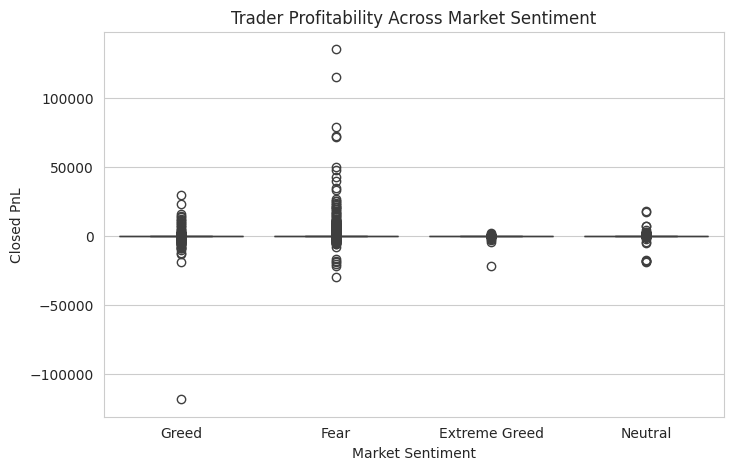

In [19]:
# Visualizing profit & loss vs sentiment
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("Trader Profitability Across Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.show()

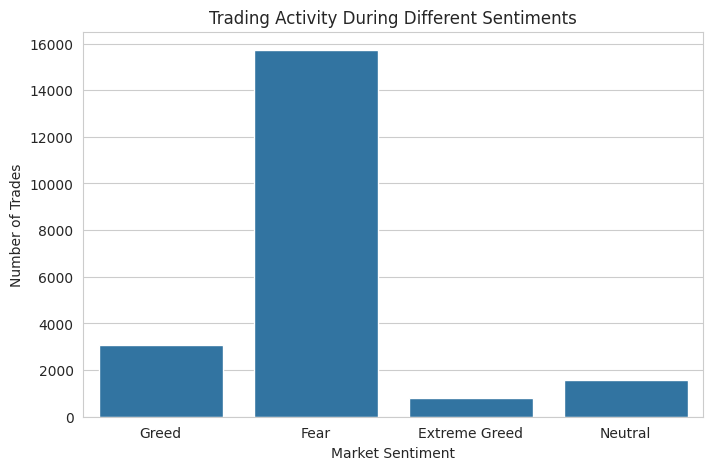

In [20]:
# Visualizing trade frequency
plt.figure(figsize=(8,5))
sns.countplot(x='classification', data=merged)
plt.title("Trading Activity During Different Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

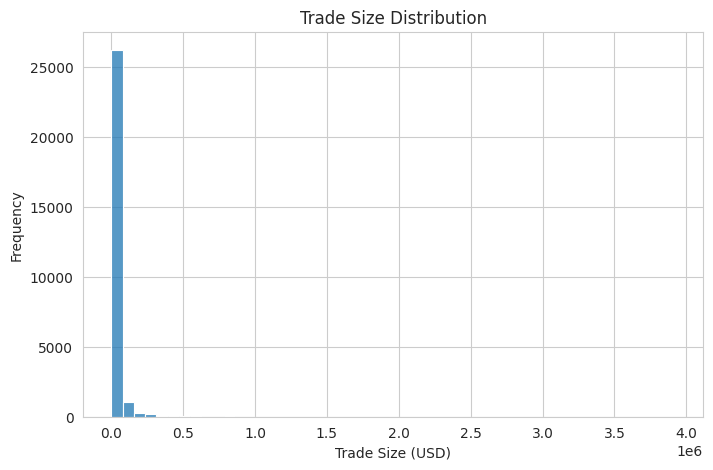

In [21]:
# Visualizing trade size distribution
plt.figure(figsize=(8,5))
sns.histplot(merged['Size USD'], bins=50)
plt.title("Trade Size Distribution")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Frequency")
plt.show()

In [22]:
merged['trade_segment'] = merged['Size USD'].apply(
    lambda x: "Large Trade" if x > merged['Size USD'].median() else "Small Trade"
)

In [23]:
trade_counts = merged['Account'].value_counts()
frequent_traders = trade_counts[trade_counts > trade_counts.median()].index
merged['trader_type'] = merged['Account'].apply(
    lambda x: "Frequent Trader" if x in frequent_traders else "Infrequent Trader"
)

In [24]:
merged['trader_type'].value_counts()

,count
trader_type,
Frequent Trader,22791
Infrequent Trader,5141


In [25]:
merged.groupby('trader_type')['Closed PnL'].mean()

,Closed PnL
trader_type,
Frequent Trader,115.694193
Infrequent Trader,185.355506


In [26]:
merged.groupby('trader_type')['win'].mean()

,win
trader_type,
Frequent Trader,0.380106
Infrequent Trader,0.369189


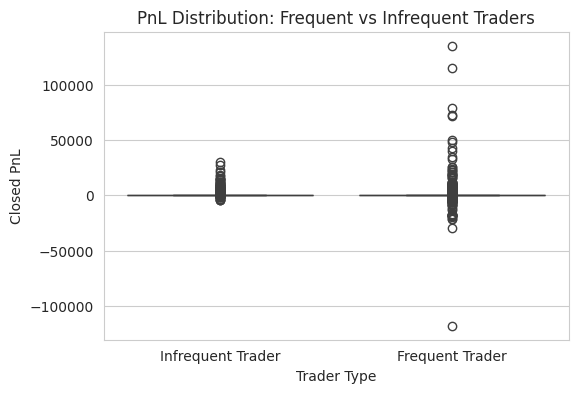

In [27]:

plt.figure(figsize=(6,4))
sns.boxplot(x='trader_type', y='Closed PnL', data=merged)
plt.title("PnL Distribution: Frequent vs Infrequent Traders")
plt.xlabel("Trader Type")
plt.ylabel("Closed PnL")
plt.show()

Insight 1:

Trading activity increases during Fear periods, suggesting traders become more active when market uncertainty rises.

Insight 2:

Average profitability appears higher during Greed sentiment, indicating bullish markets provide better trading opportunities.

Insight 3:

High-leverage traders show larger profit and loss fluctuations compared to low-leverage traders.

PART C - ACTIONABLE OUTPUT

Strategy 1 — Risk Control During Fear

During Fear sentiment, traders should reduce leverage and position sizes to manage risk because volatility tends to increase.

Strategy 2 — Momentum Strategy During Greed

During Greed sentiment, traders can moderately increase position sizes to take advantage of stronger bullish trends.

CONCLUSION:

This analysis shows that trader behavior and performance vary across different market sentiment conditions. Fear markets trigger higher trading activity, while Greed markets tend to support higher profitability.